 ## ĐỒ ÁN 1 XỬ LÍ TÍN HIỆU SỐ NHÓM 6
  

Danh sách thành viên:
1. Huỳnh Tấn Phát | MSSV: 24200144
2. Lưu Hữu Phước | MSSV: 24200150
3. Đặng Văn Trung | MSSV: 24200192
4. Trương Công Vinh | MSSV: 24200204
5. Phan Thành Nhân | MSSV: 24200140
6. Nguyễn Thanh Tuấn | MSSV: 24200199
7. Vàng Minh Trương | MSSV: 24200193

In [5]:
import numpy as np
from scipy import signal
import sounddevice as sd
import matplotlib.pyplot as plt

In [6]:
def record_sample(fs, n_channels, duration=2):
    # Bắt đầu ghi âm
    sample = sd.rec(int(duration * fs), samplerate=fs, channels=n_channels, dtype='float32')
    sd.wait()
    return sample.flatten()

In [7]:
# Thiết lập các tham số ghi âm
fs = 44100       
ts = 1 / fs
n_bits = 16       
n_channels = 1   
duration = 2     

# Tạo vector thời gian có đúng duration*fs mẫu (np.arange với bước thực có thể dư 1 mẫu)
t = np.arange(int(duration * fs)) / fs

In [8]:

import glob
from scipy.io import loadmat

# Tìm file .mat bằng ký tự đại diện * (bỏ qua tên thư mục tiếng Việt)
files = glob.glob(r'D:\*\*\*\recordings3.mat')
print(files)   # kiểm tra đã tìm thấy file chưa

data = loadmat(files[0])

Open       = data['Open'].flatten().astype(np.float64)
Close      = data['Close'].flatten().astype(np.float64)
testSample = data['testSample'].flatten().astype(np.float64)
fs         = int(data['fs'].item())

# Cập nhật thời gian và vector t theo dữ liệu thật
ts = 1 / fs
duration = len(Open) / fs
t = np.arange(len(Open)) / fs

print('Số mẫu:', len(Open), len(Close), len(testSample))
print('fs =', fs, '| duration =', duration, 's')

['D:\\Xử lí tín hiệu  số\\DoAn_Nhom6\\01 Speech Command Recognition\\recordings3.mat']
Số mẫu: 88200 88200 88200
fs = 44100 | duration = 2.0 s


In [9]:
def play(x, fs):
    """Phát âm thanh sau khi chuẩn hóa biên độ đỉnh về 0.9 (giống soundsc của MATLAB)."""
    sd.play(0.9 * x / np.max(np.abs(x)), fs)
    sd.wait()

play(Open, fs)
play(Close, fs)
play(testSample, fs)

In [10]:
# Tính tương quan chéo (tương đương hàm xcorr trong MATLAB)
# mode='full' cho ra đầy đủ các độ trễ, giống xcorr; lấy giá trị lớn nhất làm độ tương đồng
correlationOpen = np.max(signal.correlate(testSample, Open, mode='full'))
correlationClose = np.max(signal.correlate(testSample, Close, mode='full'))

print(correlationOpen)
print(correlationClose)

14.253423769958307
17.778294505551443


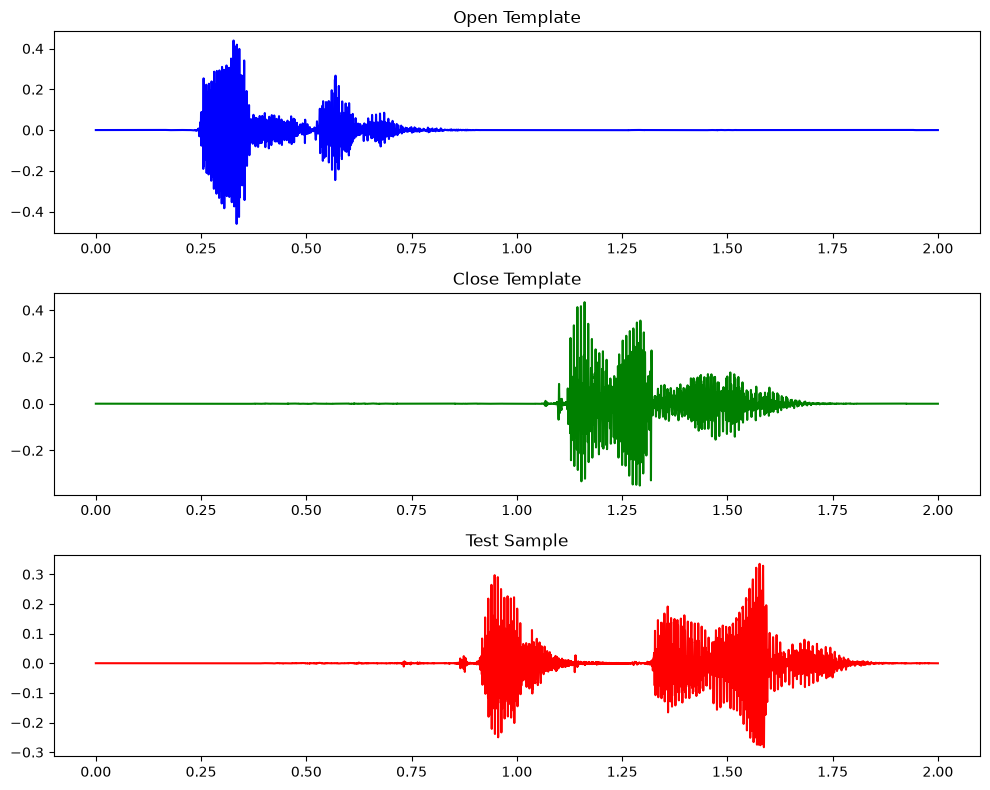

In [11]:
# Vẽ đồ thị
plt.figure(figsize=(10, 8))

plt.subplot(3, 1, 1)
plt.plot(t, Open, 'b')
plt.title('Open Template')

plt.subplot(3, 1, 2)
plt.plot(t, Close, 'g')
plt.title('Close Template')

plt.subplot(3, 1, 3)
plt.plot(t, testSample, 'r')
plt.title('Test Sample')

plt.tight_layout()
plt.show()

In [12]:
# Phân biệt lệnh
if correlationOpen > correlationClose:
    print('The "Open" command.')
else:
    print('The "Close" command.')

The "Close" command.


## 2. Năng lượng của lệnh và thêm nhiễu Gaussian

Năng lượng tín hiệu rời rạc: $E_x = \sum_{n} x^2[n]$.

Nhiễu Gaussian $w[n]$ được chuẩn hóa để có năng lượng $E_w = E_x / 10$, tức $\text{SNR} = 10\log_{10}(E_x/E_w) = 10\ \text{dB}$.

In [13]:
def energy(x):
    """Năng lượng tín hiệu: tổng bình phương các mẫu."""
    return float(np.sum(x ** 2))

def add_noise(x, energy_ratio=0.1, rng=None):
    """Thêm nhiễu Gaussian có năng lượng = energy_ratio * năng lượng của x."""
    rng = rng if rng is not None else np.random.default_rng()
    noise = rng.standard_normal(len(x))
    noise *= np.sqrt(energy_ratio * energy(x) / energy(noise))  # chuẩn hóa năng lượng nhiễu
    return x + noise, noise

def classify(test, open_t, close_t):
    """Nhận dạng bằng tương quan chéo (đúng theo đề). Trả về (nhãn, corr_open, corr_close)."""
    c_open = np.max(signal.correlate(test, open_t, mode='full', method='fft'))
    c_close = np.max(signal.correlate(test, close_t, mode='full', method='fft'))
    return ('Open' if c_open > c_close else 'Close'), c_open, c_close

# Năng lượng của các lệnh
E_open, E_close, E_test = energy(Open), energy(Close), energy(testSample)
print(f'Năng lượng "Open"     : {E_open:.4f}')
print(f'Năng lượng "Close"    : {E_close:.4f}')
print(f'Năng lượng testSample : {E_test:.4f}')

Năng lượng "Open"     : 178.2243
Năng lượng "Close"    : 190.7417
Năng lượng testSample : 164.7279


Năng lượng nhiễu (Open) : 17.8224  (= E_open/10 = 17.8224)
SNR (Open)  = 10.00 dB
SNR (Close) = 10.00 dB
Open + nhiễu         -> Open   corr_Open=178.255  corr_Close=29.703 (đúng là Open: ĐÚNG)
Close + nhiễu        -> Close  corr_Open=29.522  corr_Close=191.071 (đúng là Close: ĐÚNG)
testSample + nhiễu   -> Close  corr_Open=14.036  corr_Close=17.727


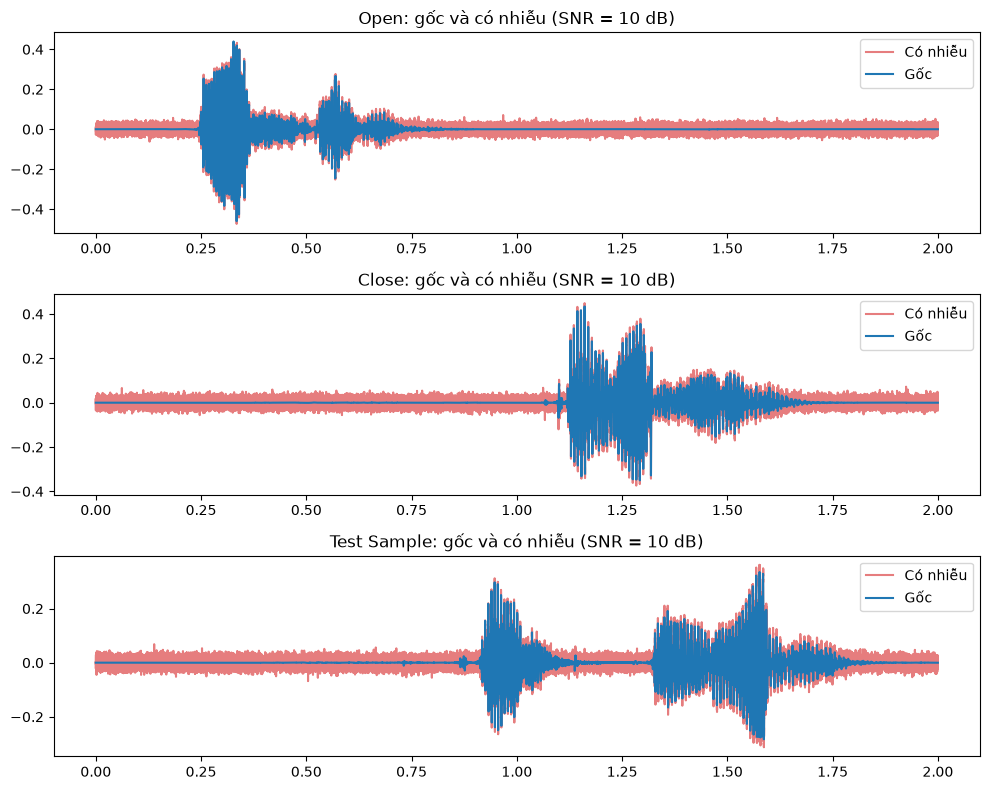

In [14]:
# Thêm nhiễu Gaussian có năng lượng bằng 1/10 năng lượng tín hiệu
rng = np.random.default_rng(42)   # cố định seed để kết quả lặp lại được
Open_noisy, noise_open = add_noise(Open, 0.1, rng)
Close_noisy, noise_close = add_noise(Close, 0.1, rng)
Test_noisy, noise_test = add_noise(testSample, 0.1, rng)

print(f'Năng lượng nhiễu (Open) : {energy(noise_open):.4f}  (= E_open/10 = {E_open/10:.4f})')
print(f'SNR (Open)  = {10*np.log10(E_open/energy(noise_open)):.2f} dB')
print(f'SNR (Close) = {10*np.log10(E_close/energy(noise_close)):.2f} dB')

# Nhận dạng các tín hiệu đã có nhiễu, so với mẫu chuẩn sạch
for name, x, expected in [('Open + nhiễu', Open_noisy, 'Open'),
                          ('Close + nhiễu', Close_noisy, 'Close'),
                          ('testSample + nhiễu', Test_noisy, None)]:
    label, co, cc = classify(x, Open, Close)
    exp = f' (đúng là {expected}: {"ĐÚNG" if label == expected else "SAI"})' if expected else ''
    print(f'{name:20s} -> {label:5s}  corr_Open={co:.3f}  corr_Close={cc:.3f}{exp}')

# Vẽ tín hiệu trước và sau khi thêm nhiễu
plt.figure(figsize=(10, 8))
for k, (x, xn, title) in enumerate([(Open, Open_noisy, 'Open'),
                                    (Close, Close_noisy, 'Close'),
                                    (testSample, Test_noisy, 'Test Sample')], start=1):
    plt.subplot(3, 1, k)
    plt.plot(t, xn, color='tab:red', alpha=0.6, label='Có nhiễu')
    plt.plot(t, x, color='tab:blue', label='Gốc')
    plt.title(f'{title}: gốc và có nhiễu (SNR = 10 dB)')
    plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [15]:
# Kiểm tra độ bền vững: lặp lại với nhiều lần nhiễu ngẫu nhiên khác nhau (Monte Carlo)

true_label = 'Open'   

n_trials = 200
rng = np.random.default_rng(0)
tests = {'Open + nhiễu': (Open, 'Open'),
         'Close + nhiễu': (Close, 'Close'),
         'testSample + nhiễu': (testSample, true_label)}

for name, (x, expected) in tests.items():
    correct = sum(classify(add_noise(x, 0.1, rng)[0], Open, Close)[0] == expected
                  for _ in range(n_trials))
    print(f'{name:20s}: đúng {correct}/{n_trials} = {100*correct/n_trials:.1f}%')

Open + nhiễu        : đúng 200/200 = 100.0%
Close + nhiễu       : đúng 200/200 = 100.0%
testSample + nhiễu  : đúng 0/200 = 0.0%


## 3. Giải pháp tăng độ chính xác

Các cải tiến:

1. **Lọc thông dải 100–4000 Hz** (băng tần chủ yếu của tiếng nói) để loại bỏ nhiễu ngoài băng và thành phần một chiều.
2. **Cắt bỏ đoạn im lặng** ở đầu và cuối bằng ngưỡng năng lượng theo khung, để tương quan không bị ảnh hưởng bởi vị trí bắt đầu nói và khoảng lặng.
3. **Tương quan chéo chuẩn hóa**: chia cho $\sqrt{E_x E_y}$, để giá trị nằm trong $[-1, 1]$ và không phụ thuộc mẫu nào ghi to hơn.



In [16]:
def bandpass(x, fs, low=100, high=4000, order=4):
    """Lọc thông dải Butterworth pha không (sosfiltfilt để không làm lệch pha)."""
    sos = signal.butter(order, [low, high], btype='band', fs=fs, output='sos')
    return signal.sosfiltfilt(sos, x)

def trim_silence(x, fs, frame_ms=20, thr_ratio=0.05):
    """Cắt đoạn im lặng đầu/cuối: giữ từ khung đầu tiên đến khung cuối cùng có năng lượng vượt ngưỡng."""
    n = int(fs * frame_ms / 1000)
    n_frames = len(x) // n
    frame_energy = np.sum(x[:n_frames * n].reshape(n_frames, n) ** 2, axis=1)
    active = np.where(frame_energy > thr_ratio * frame_energy.max())[0]
    if len(active) == 0:
        return x
    return x[active[0] * n:(active[-1] + 1) * n]

def preprocess(x, fs):
    x = x - np.mean(x)          # bỏ thành phần một chiều
    x = bandpass(x, fs)         # lọc thông dải
    x = trim_silence(x, fs)     # cắt khoảng lặng
    return x

def norm_xcorr_max(x, y):
    """Giá trị lớn nhất của tương quan chéo chuẩn hóa, thuộc [-1, 1]."""
    c = signal.correlate(x, y, mode='full', method='fft')
    return np.max(c) / np.sqrt(energy(x) * energy(y))

def classify_improved(test, open_p, close_p, fs):
    """open_p, close_p là mẫu chuẩn đã tiền xử lý sẵn."""
    tp = preprocess(test, fs)
    c_open, c_close = norm_xcorr_max(tp, open_p), norm_xcorr_max(tp, close_p)
    return ('Open' if c_open > c_close else 'Close'), c_open, c_close

# Tiền xử lý mẫu chuẩn một lần
Open_p, Close_p = preprocess(Open, fs), preprocess(Close, fs)

# Kết quả trên tín hiệu sạch
label, co, cc = classify_improved(testSample, Open_p, Close_p, fs)
print(f'testSample (sạch): {label}  corr_Open={co:.3f}  corr_Close={cc:.3f}')

testSample (sạch): Close  corr_Open=0.091  corr_Close=0.098


E_nhiễu/E_tín hiệu =  0.1 (SNR =  10.0 dB): cơ bản   0.0%  |  cải tiến   0.0%
E_nhiễu/E_tín hiệu =  0.5 (SNR =   3.0 dB): cơ bản   0.0%  |  cải tiến   0.0%
E_nhiễu/E_tín hiệu =    1 (SNR =  -0.0 dB): cơ bản   0.0%  |  cải tiến   2.0%
E_nhiễu/E_tín hiệu =    2 (SNR =  -3.0 dB): cơ bản   0.0%  |  cải tiến   6.0%
E_nhiễu/E_tín hiệu =    5 (SNR =  -7.0 dB): cơ bản   0.0%  |  cải tiến   6.0%


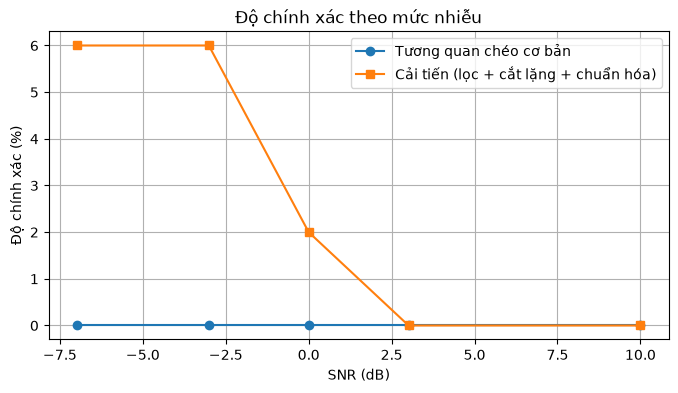

In [17]:
# So sánh phương pháp cơ bản và phương pháp cải tiến theo mức nhiễu
# energy_ratio = E_nhiễu / E_tín hiệu: 0.1 (SNR 10 dB) ... 5 (SNR khoảng -7 dB)
ratios = [0.1, 0.5, 1, 2, 5]
n_trials = 100
rng = np.random.default_rng(1)

acc_basic, acc_improved = [], []
for r in ratios:
    ok_b = ok_i = 0
    for _ in range(n_trials):
        xn, _ = add_noise(testSample, r, rng)
        ok_b += classify(xn, Open, Close)[0] == true_label
        ok_i += classify_improved(xn, Open_p, Close_p, fs)[0] == true_label
    acc_basic.append(100 * ok_b / n_trials)
    acc_improved.append(100 * ok_i / n_trials)
    print(f'E_nhiễu/E_tín hiệu = {r:>4} (SNR = {-10*np.log10(r):5.1f} dB): '
          f'cơ bản {acc_basic[-1]:5.1f}%  |  cải tiến {acc_improved[-1]:5.1f}%')

snr_db = [-10 * np.log10(r) for r in ratios]
plt.figure(figsize=(8, 4))
plt.plot(snr_db, acc_basic, 'o-', label='Tương quan chéo cơ bản')
plt.plot(snr_db, acc_improved, 's-', label='Cải tiến (lọc + cắt lặng + chuẩn hóa)')
plt.xlabel('SNR (dB)')
plt.ylabel('Độ chính xác (%)')
plt.title('Độ chính xác theo mức nhiễu')
plt.grid(True)
plt.legend()
plt.show()

In [30]:
# Kết quả nhận dạng trên testSample sạch, chưa thêm nhiễu
label, co, cc = classify(testSample, Open, Close)
print('Cơ bản  :', label, f'| corr_Open={co:.4f}, corr_Close={cc:.4f}')

label2, co2, cc2 = classify_improved(testSample, Open_p, Close_p, fs)
print('Cải tiến:', label2, f'| corr_Open={co2:.4f}, corr_Close={cc2:.4f}')
print('true_label đang đặt =', true_label)

#Âm thanh trước 

sd.play(Open / np.max(np.abs(Open)), fs); sd.wait()
sd.play(Close / np.max(np.abs(Close)), fs); sd.wait()
sd.play(testSample / np.max(np.abs(testSample)), fs); sd.wait()

Cơ bản  : Close | corr_Open=14.2534, corr_Close=17.7783
Cải tiến: Close | corr_Open=0.0908, corr_Close=0.0978
true_label đang đặt = Open


In [34]:
# Âm thanh sau khi xử lí
print('Open sau xử lý');       sd.play(Open_p / np.max(np.abs(Open_p)), fs); sd.wait()
print('Close sau xử lý');      sd.play(Close_p / np.max(np.abs(Close_p)), fs); sd.wait()
testSample_p = preprocess(testSample, fs)
print('testSample sau xử lý'); sd.play(testSample_p / np.max(np.abs(testSample_p)), fs); sd.wait()

Open sau xử lý
Close sau xử lý
testSample sau xử lý
